In [40]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("/Users/tahamac/malicious-content-analysis/data/phishing_email.csv")


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0
...,...,...
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1


In [6]:
X = df["text_combined"]
X

0        hpl nom may 25 2001 see attached file hplno 52...
1        nom actual vols 24 th forwarded sabrae zajac h...
2        enron actuals march 30 april 1 201 estimated a...
3        hpl nom may 30 2001 see attached file hplno 53...
4        hpl nom june 1 2001 see attached file hplno 60...
                               ...                        
82481    info advantageapartmentscom infoadvantageapart...
82482    monkeyorg helpdeskmonkeyorg monkeyorg hi josep...
82483    help center infohelpcentercoza_infohelpcenterc...
82484    metamask infosofamekarcom verify metamask wall...
82485    fastway infofastwaycoza_infofastwaycoza_infofa...
Name: text_combined, Length: 82486, dtype: str

In [82]:
y = df["label"]
y.value_counts()

label
1    42891
0    39595
Name: count, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% for evaluation
    random_state=42,    # reproducibility
    stratify=y          # preserve class proportions
)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(

    # Keep only the 5000 most informative words
    # instead of all possible words.
    max_features=5000,

    # Ignore extremely common words
    # appearing in more than 95% of emails.
    max_df=0.95,

    # Ignore words appearing only once.
    min_df=2,

    # Use single words AND pairs of words.
    #
    # Example:
    # "verify"
    #
    # "verify account"
    #
    # This often improves phishing detection.
    ngram_range=(1, 2),

    # Remove common English stopwords
    stop_words="english")


In [39]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4824355 stored elements and shape (65988, 5000)>

In [40]:
X_test_tfidf = tfidf.transform(X_test)

In [41]:
print("Training matrix shape:")
print(X_train_tfidf.shape)

print()

print("Testing matrix shape:")
print(X_test_tfidf.shape)

Training matrix shape:
(65988, 5000)

Testing matrix shape:
(16498, 5000)


In [42]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['00' '00 00' '00 pm' '000' '000 00' '000 000' '000 mmbtu' '0000'
 '0000 utc' '0000000' '001' '0025' '01' '01 enron' '01 hourahead' '0100'
 '0100 ilug' '0100 opensuse' '02' '02 hourahead']


In [45]:
# ==========================================
# 11. Import Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression


# ==========================================
# 12. Create the model
# ==========================================

# We create an empty Logistic Regression model.
#
# It will learn the coefficients (β)
# associated with each TF-IDF feature.

model = LogisticRegression()


# ==========================================
# 13. Train the model
# ==========================================

# EXACTLY what you studied:
#
# fit(X, y)
#
# Here:
#
# X = TF-IDF matrix
#
# y = real labels

model.fit(X_train_tfidf, y_train)


# ==========================================
# 14. Make predictions
# ==========================================

# Predict the classes:
#
# 0 = legitimate
# 1 = phishing

y_pred = model.predict(X_test_tfidf)


# ==========================================
# 15. Predict probabilities
# ==========================================

# Logistic Regression naturally outputs
# probabilities thanks to the sigmoid.

y_proba = model.predict_proba(X_test_tfidf)

print(y_proba[:5])

[[1.37126344e-02 9.86287366e-01]
 [9.78174944e-01 2.18250556e-02]
 [2.40755542e-01 7.59244458e-01]
 [8.51794215e-04 9.99148206e-01]
 [9.98568188e-01 1.43181245e-03]]


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


print("Accuracy :",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall   :",
      recall_score(y_test, y_pred))

print("F1-score :",
      f1_score(y_test, y_pred))


print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy : 0.9951865222623345
Precision: 0.9939975990396158
Recall   : 0.9963898916967509
F1-score : 0.9951923076923077

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       831
           1       0.99      1.00      1.00       831

    accuracy                           1.00      1662
   macro avg       1.00      1.00      1.00      1662
weighted avg       1.00      1.00      1.00      1662



In [74]:
email=np.array(["daily top 10 reynaldontocoelebandaimusejp daily top 10 cnncom top videos stories aug 1 2008 358 pm edt top 10 videos 1 montauk monster httpwwwcnncomvideopartnersemailindexhtmlurlvideous20080731moosmontaukmonstercnn devil dog turtle montauk monster cnns jeanne moos asks thing 2 racy photos toddlers mom httpwwwcnncomvideopartnersemailindexhtmlurlvideocrime20080731ngracyphotoscnn 3 news absurd episode 54 httpwwwcnncomvideopartnersemailindexhtmlurlvideopodcastsabsurdsite20080801notaepisode54cnn 4 police beating dispute httpwwwcnncomvideopartnersemailindexhtmlurlvideous20080731levspolicevideocnn 5 mom pleads girls return httpwwwcnncomvideopartnersemailindexhtmlurlvideocrime20080801hillbossreighpleacnn 6 defendant fakes heart attack httpwwwcnncomvideopartnersemailindexhtmlurlvideocrime20080801dntfakeheartattackmxfwhio 7 killer carried victims head httpwwwcnncomvideopartnersemailindexhtmlurlvideoworld20080731natpkgcanbusdecapitationctv 8 murder confession recanted httpwwwcnncomvideopartnersemailindexhtmlurlvideoworld20080801blakebrazilteenmurderitn 9 anthrax suspects home httpwwwcnncomvideopartnersemailindexhtmlurlvideous20080801vondrbruceivinshomecnn 10 hecklers interrupt obama talk httpwwwcnncomvideopartnersemailindexhtmlurlvideopolitics20080801sotflobamaprotestersbaynews9 top 10 stories 1 suspect beheading identified httpwwwcnncom2008worldamericas0801canadabeheadingindexhtml canadian police say vince weiguang li 40 edmonton charged seconddegree murder beheading man bus 2 judge taken last jena 6 cases httpwwwcnncom2008crime0801jena6appealindexhtml 3 people mag gets pittjolie pix httpwwwcnncom2008showbizmovies0801brangelinaphotosapindexhtml 4 attack toronto called racial httpwwwcnncom2008worldamericas0801canadaattackapindexhtml 5 ireporters unusual names httpwwwcnncom2008living0801unusualnamesirptindexhtml 6 mother pleads childs return httpwwwcnncom2008crime0801rockefellerkidnappingindexhtml 7 karadzic made deal us httpwwwcnncom2008worldeurope0801karadzictrialindexhtml 8 suspect arrested swim killings httpwwwcnncom2008crime0801wisconsinshootingapindexhtml 9 anthrax suspect apparent suicide httpwwwcnncom2008crime0801anthraxdeathindexhtml 10 mccain obama criticism fair httpwwwcnncom2008politics0801campaignwrapindexhtml cnn trusted name news cable news network lp lllp one cnn center atlanta georgia 30303 2008 cable news network lp lllp time warner company rights reserved please send comments suggestions going httpwwwcnncomfeedback read privacy guidelines going httpwwwcnncomprivacyhtml agreed receive email cnncom result cnncom preference settings manage settings go httpwwwcnncomlinktobnmanagehtml unsubscribe daily top 10 go httpcgicnncommclike38da22de552453ff94c9a9174fd4fdfegvcceaschallengecclcnndailytop10 tue 05 aug 2008 220925 0500 cnncom daily top 10 "])

In [75]:
x_test=tfidf.transform(email)
x_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 326 stored elements and shape (1, 5000)>

In [76]:
Y=model.predict(x_test)
Y

array([1])

In [78]:
import matplotlib.pyplot as plt

In [53]:
import os

def load_emails(folder):

    emails = []

    for filename in os.listdir(folder):

        path = os.path.join(folder, filename)

        if os.path.isfile(path):

            try:
                with open(path,
                         encoding="latin1",
                         errors="ignore") as f:

                    emails.append(f.read())

            except:
                pass

    return emails

In [54]:
easy = load_emails(
    "/Users/tahamac/malicious-content-analysis/data/spamassassin/easy_ham"
)

easy2 = load_emails(
    "/Users/tahamac/malicious-content-analysis/data/spamassassin/easy_ham_2"
)

hard = load_emails(
    "/Users/tahamac/malicious-content-analysis/data/spamassassin/hard_ham"
)

ham = easy + easy2 + hard

print(len(ham))

4153


In [55]:
import pandas as pd

phish = pd.read_csv(
    "/Users/tahamac/malicious-content-analysis/data/phishing_email.csv"
)

phish = phish[
    phish["label"] == 1
]
phish

,text_combined,label
3503,link dwl g 510 802 11 g wireless pci lan adapt...,1
3504,indemand payperview movies sports wed 15 sep 2...,1
3505,want lose 19 weight try adipren hello special ...,1
3506,cialis xanax valium viagra low price prescript...,1
3507,pre order see image click indelible backscatte...,1
...,...,...
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1


In [56]:
ham_df = pd.DataFrame({

    "text": ham,

    "label": 0

})
ham_df

,text,label
0,From fork-admin@xent.com Tue Sep 24 17:55:30 ...,0
1,From rpm-list-admin@freshrpms.net Mon Sep 9 ...,0
2,From secprog-return-625-jm=jmason.org@security...,0
3,Return-Path: nas@python.ca\nDelivery-Date: Thu...,0
4,From fork-admin@xent.com Thu Aug 29 11:03:51 ...,0
...,...,...
4148,Return-Path: <Online#3.19660.88-olLIlW2o6IOeGR...,0
4149,Return-Path: <Online#3.20340.74-k8cCgc95N6xNP9...,0
4150,From razor-users-admin@lists.sourceforge.net ...,0
4151,Return-Path: <Online#3.20467.ac-q5A1l6tzmmPhUd...,0


In [57]:
phish_df = pd.DataFrame({

    "text": phish["text_combined"],

    "label": 1

})
phish_df

,text,label
3503,link dwl g 510 802 11 g wireless pci lan adapt...,1
3504,indemand payperview movies sports wed 15 sep 2...,1
3505,want lose 19 weight try adipren hello special ...,1
3506,cialis xanax valium viagra low price prescript...,1
3507,pre order see image click indelible backscatte...,1
...,...,...
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1


In [58]:
phish_df = phish_df.sample(

    n=len(ham_df),

    random_state=42

)

In [59]:
df = pd.concat(
    [ham_df, phish_df],
    ignore_index=True
)
df

,text,label
0,From fork-admin@xent.com Tue Sep 24 17:55:30 ...,0
1,From rpm-list-admin@freshrpms.net Mon Sep 9 ...,0
2,From secprog-return-625-jm=jmason.org@security...,0
3,Return-Path: nas@python.ca\nDelivery-Date: Thu...,0
4,From fork-admin@xent.com Thu Aug 29 11:03:51 ...,0
...,...,...
8301,daily top 10 4953171dualnetcom daily top 10 cn...,1
8302,carling ken htanoglusimyahidrolikcom itsaoagon...,1
8303,lr almost acquaintances free cable tv exotic i...,1
8304,lidia darden melisadebugdillwolframcom couldnt...,1


In [61]:
df.to_csv(
    "/Users/tahamac/malicious-content-analysis/data/final_dataset.csv",
    index=False
)

In [62]:
X=df['text']
y=df['label']

In [63]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% for evaluation
    random_state=42,    # reproducibility
    stratify=y          # preserve class proportions
)

In [64]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1177476 stored elements and shape (6644, 5000)>

In [65]:
X_test_tfidf = tfidf.transform(X_test)

In [66]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:])

['00' '00 00' '00 0100' ... 'zzzzteana' 'zzzzteana unsubscribe'
 'zzzzteana yahoogroups']


In [67]:
# ==========================================
# 11. Import Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression


# ==========================================
# 12. Create the model
# ==========================================

# We create an empty Logistic Regression model.
#
# It will learn the coefficients (β)
# associated with each TF-IDF feature.

model = LogisticRegression()


# ==========================================
# 13. Train the model
# ==========================================

# EXACTLY what you studied:
#
# fit(X, y)
#
# Here:
#
# X = TF-IDF matrix
#
# y = real labels

model.fit(X_train_tfidf, y_train)


# ==========================================
# 14. Make predictions
# ==========================================

# Predict the classes:
#
# 0 = legitimate
# 1 = phishing

y_pred = model.predict(X_test_tfidf)


# ==========================================
# 15. Predict probabilities
# ==========================================

# Logistic Regression naturally outputs
# probabilities thanks to the sigmoid.

y_proba = model.predict_proba(X_test_tfidf)

print(y_proba[:5])

[[0.00859745 0.99140255]
 [0.01153053 0.98846947]
 [0.08283699 0.91716301]
 [0.98533654 0.01466346]
 [0.98396571 0.01603429]]


In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


print("Accuracy :",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall   :",
      recall_score(y_test, y_pred))

print("F1-score :",
      f1_score(y_test, y_pred))


print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy : 0.9951865222623345
Precision: 0.9939975990396158
Recall   : 0.9963898916967509
F1-score : 0.9951923076923077

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       831
           1       0.99      1.00      1.00       831

    accuracy                           1.00      1662
   macro avg       1.00      1.00      1.00      1662
weighted avg       1.00      1.00      1.00      1662



In [115]:
email=np.array(["claim your 100$ we need just your password and username"])

In [116]:
x_test=tfidf.transform(email)
x_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 5000)>

In [117]:
Y=model.predict(x_test)
Y

array([1])

In [118]:
new_df=pd.read_csv("/Users/tahamac/malicious-content-analysis/data/phishing_legit_dataset_KD_10000.csv")
new_df

,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80
...,...,...,...,...,...
9995,Subject: Code review summary\n\nI booked the l...,0,legitimate,low,0.98
9996,"Hello, we talked about meeting again after the...",1,romance_dating,medium,0.83
9997,"Hi there, we talked about meeting again after ...",1,romance_dating,medium,0.78
9998,"Dear user, this is an expires midnight notice ...",1,urgency,high,0.88


In [121]:
new_df2=pd.read_csv("/Users/tahamac/malicious-content-analysis/data/Phishing_Emaildset.csv")
new_df2

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...,...
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email


In [123]:
df1 = new_df[['text','label']].copy()
df1

,text,label
0,Subject: Office maintenance\n\nThanks for your...,0
1,"Hello, your profile has been locked. Use the s...",1
2,"Hi there, congratulations! You are the winner ...",1
3,"Attention, this is the fraud prevention accoun...",1
4,"Notice, your profile has been restricted. Use ...",1
...,...,...
9995,Subject: Code review summary\n\nI booked the l...,0
9996,"Hello, we talked about meeting again after the...",1
9997,"Hi there, we talked about meeting again after ...",1
9998,"Dear user, this is an expires midnight notice ...",1


In [124]:
df1.dropna(inplace=True)

In [125]:
df1.drop_duplicates(subset='text', inplace=True)

In [126]:
df1['label'].value_counts()

label
1    6000
0    3956
Name: count, dtype: int64

In [127]:
df2 = new_df2[['Email Text','Email Type']].copy()

In [128]:
df2.columns = ['text','label']

In [129]:
df2['label'] = df2['label'].map({
    'Safe Email':0,
    'Phishing Email':1
})

In [130]:
df2 = df2[df2['text'].notna()]

In [131]:
df2 = df2[df2['text'].str.strip() != '']
df2 = df2[df2['text'].str.lower() != 'empty']

In [132]:
df2.drop_duplicates(subset='text', inplace=True)

In [133]:
import re

def clean_email(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', ' ', text)

    # remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # remove numbers
    text = re.sub(r'\d+', ' ', text)

    # remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [134]:
df1['text'] = df1['text'].apply(clean_email)
df2['text'] = df2['text'].apply(clean_email)

In [135]:
df1 = df1[df1['text'].str.split().str.len() > 5]
df2 = df2[df2['text'].str.split().str.len() > 5]

In [136]:
df1.sample(10)

,text,label
6643,subject meeting follow up good morning the upd...,0
2065,attention we talked about meeting again after ...,1
7045,subject quarterly roadmap quick reminder about...,0
9147,subject code review summary quick reminder abo...,0
2048,subject weekly status report hi team sharing t...,0
9772,subject team lunch planning attaching the draf...,0
9603,hi there the it department detected a malware ...,1
517,hi there you have a new notification please cl...,1
5448,notice you have a new notification please clic...,1
2351,subject code review summary attaching the draf...,0


In [137]:
df2.sample(10)

,text,label
1047,action required attend west power trading staf...,0
11552,mail delivery failed returning message to send...,1
742,re resume vasant i agree vince from vasant sha...,0
9217,vernon i m changing the instructions in the sp...,0
11375,on thursday september michael mckay wrote on t...,0
10953,re mna hi dave here is a revised draft for dis...,0
1379,specialize in hard to qualify borrowers novemb...,1
12156,url date t will the last person to leave the t...,0
7935,ena group expenses guys reference to a below h...,0
56,free portable dvd player offer valid only to r...,1


In [439]:
df3=pd.read_csv("/Users/tahamac/malicious-content-analysis/data/datasetzenodo.csv")
df4=df3.drop(columns='subject')
df4.rename(columns={"body": "text"}, inplace=True)


,text,label
0,content - length : 3386 apple-iss research cen...,0
1,"lang classification grimes , joseph e . and ba...",0
2,i am posting this inquiry for sergei atamas ( ...,0
3,a colleague and i are researching the differin...,0
4,earlier this morning i was on the phone with a...,0
...,...,...
2854,"raquel 's casino , inc . is awarding a cruise ...",1
2855,"the list owner of : "" kiddin "" has invited you...",1
2856,"judging from the return post , i must have sou...",0
2857,gotcha ! there are two separate fallacies in t...,0


In [440]:
df4['text'] = df4['text'].apply(clean_email)

In [441]:
final_df = pd.concat([df1, df2,df4], ignore_index=True)

In [442]:
final_df.to_csv(
    "/Users/tahamac/malicious-content-analysis/data/final_dataset2.csv",
    index=False
)

In [443]:
final_df

,text,label
0,subject office maintenance thanks for your hel...,0
1,hello your profile has been locked use the sec...,1
2,hi there congratulations you are the winner of...,1
3,attention this is the fraud prevention account...,1
4,notice your profile has been restricted use th...,1
...,...,...
30207,raquel s casino inc is awarding a cruise to a ...,1
30208,the list owner of kiddin has invited you to jo...,1
30209,judging from the return post i must have sound...,0
30210,gotcha there are two separate fallacies in the...,0


In [ ]:
import random

greetings = [
    "Hello",
    "Hi",
    "Good morning",
    "Good evening",
]

messages = [
    "Can we meet tomorrow?",
    "Please call me when you are free.",
    "Thank you for your help.",
    "I hope you are doing well.",
    "See you next week.",
    "Let me know what you think.",
    "The meeting has been postponed.",
    "I sent you the document.",
    "Please review the report.",
    "I will contact you later."
]

names = [
    "Hassan",
    "Taha",
    "Ahmed",
    "Sara",
    "Youssef",
    "Mariam"
]

emails = []

for _ in range(200):
    email = f"{random.choice(greetings)} {random.choice(names)}, {random.choice(messages)}"
    emails.append(email)

df_short_legit = pd.DataFrame({
    "text": emails,
    "label": 0   # legitimate
})

df_short_legit.to_csv("short_legitimate_emails.csv", index=False)

In [660]:
final_df = pd.concat(
    [final_df, df_short_legit],
    ignore_index=True
)
final_df.to_csv(
    "/Users/tahamac/malicious-content-analysis/data/final_dataset2.csv",
    index=False
)

In [444]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [458]:
fX=final_df['text']
fY=final_df['label']

In [459]:
X_train, X_test, y_train, y_test = train_test_split(
    fX,
    fY,
    test_size=0.2,      # 20% for evaluation
    random_state=42,    # reproducibility
)

In [460]:
X_train_tfidf2 = tfidf.fit_transform(X_train)
X_train_tfidf2

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1806491 stored elements and shape (24329, 10000)>

In [461]:
X_test_tfidf2 = tfidf.transform(X_test)

In [462]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:200])

['aa' 'aaa' 'aaas' 'ab' 'abilities' 'ability' 'able' 'aboard' 'aboriginal'
 'abroad' 'absence' 'absolute' 'absolutely' 'absolutely free' 'abstract'
 'abstract paper' 'abstract submission' 'abstract words' 'abstracts'
 'abstracts invited' 'abstracts papers' 'abstracts received'
 'abstracts sent' 'abstracts submitted' 'abuse' 'ac' 'ac il' 'ac jp'
 'ac uk' 'ac za' 'academia' 'academic' 'academic graphics'
 'academic publishers' 'academics' 'academy' 'academy sciences' 'accent'
 'accents' 'accept' 'acceptable' 'acceptance' 'accepted' 'accepted papers'
 'accepting' 'access' 'access code' 'access confirm' 'access enter'
 'access expire' 'access limited' 'access reset' 'access update'
 'access validate' 'accessed' 'accessible' 'accessing' 'accessories'
 'accident' 'accommodate' 'accommodation' 'accommodations' 'accomodation'
 'accompanied' 'accompanying' 'accomplish' 'accordance' 'according'
 'accordingly' 'account' 'account access' 'account authenticate'
 'account holder' 'account immediate'

In [464]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


print("Accuracy :",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall   :",
      recall_score(y_test, y_pred))

print("F1-score :",
      f1_score(y_test, y_pred))


print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy : 0.9829031727765905
Precision: 0.9829391236913533
Recall   : 0.976878612716763
F1-score : 0.9798994974874372

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3488
           1       0.98      0.98      0.98      2595

    accuracy                           0.98      6083
   macro avg       0.98      0.98      0.98      6083
weighted avg       0.98      0.98      0.98      6083



In [463]:
# ==========================================
# 11. Import Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

from xgboost as xgb

# ==========================================
# 12. Create the model
# ==========================================

# We create an empty Logistic Regression model.
#
# It will learn the coefficients (β)
# associated with each TF-IDF feature.

#model = LogisticRegression()

model = xgb.XGBClassifier(
    n_estimators=100,                  # number of boosting trees
    max_depth=3,                      
    random_state=42,
)


# ==========================================
# 13. Train the model
# ==========================================

# EXACTLY what you studied:
#
# fit(X, y)
#
# Here:
#
# X = TF-IDF matrix
#
# y = real labels

model.fit(X_train_tfidf2, y_train)


# ==========================================
# 14. Make predictions
# ==========================================

# Predict the classes:
#
# 0 = legitimate
# 1 = phishing

y_pred = model.predict(X_test_tfidf2)


# ==========================================
# 15. Predict probabilities
# ==========================================

# Logistic Regression naturally outputs
# probabilities thanks to the sigmoid.

y_proba = model.predict_proba(X_test_tfidf2)


In [647]:
!pip insall xgboost

zsh:1: command not found: pip


In [656]:
email = """
hello ayman how are you send me your credit card 

"""

In [657]:
x_test=tfidf.transform([email])
print(x_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 1206)	0.4739681277767888
  (0, 2010)	0.4483265302711445
  (0, 2011)	0.5427785633608847
  (0, 3905)	0.39421896481805174
  (0, 7949)	0.3526193061085567


In [658]:
proba = model.predict_proba(x_test)[0]

print("Legitimate:", proba[0])
print("Phishing:", proba[1])

Legitimate: 0.18907010844751682
Phishing: 0.8109298915524832


In [655]:

print("proba to be phishing :",proba[1])
if proba[0] >= 0.445:
    print("Legitimate")
else:
    print("Phishing")

proba to be phishing : 0.32098488966589317
Legitimate


In [652]:
import joblib

joblib.dump(tfidf, "../models/tfidf_model.pkl")
joblib.dump(model, "../models/logistic_model.pkl")

['../models/logistic_model.pkl']

In [659]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

with open("../results/classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3488
           1       0.98      0.98      0.98      2595

    accuracy                           0.98      6083
   macro avg       0.98      0.98      0.98      6083
weighted avg       0.98      0.98      0.98      6083



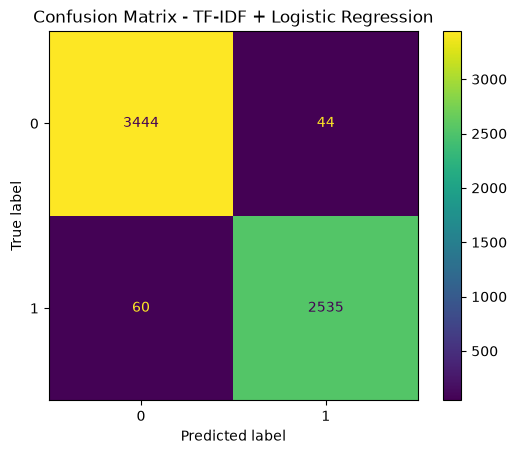

In [661]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - TF-IDF + Logistic Regression")

plt.savefig("../results/confusion_matrix.png")

plt.show()

In [662]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

with open("../results/metrics.txt", "w") as f:

    f.write("TF-IDF + Logistic Regression\n\n")

    f.write(f"Accuracy  : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1-score  : {f1:.4f}\n")

In [669]:
X_test_tfidf = tfidf.transform(X_test)

In [670]:
print(type(X_test))

<class 'pandas.Series'>


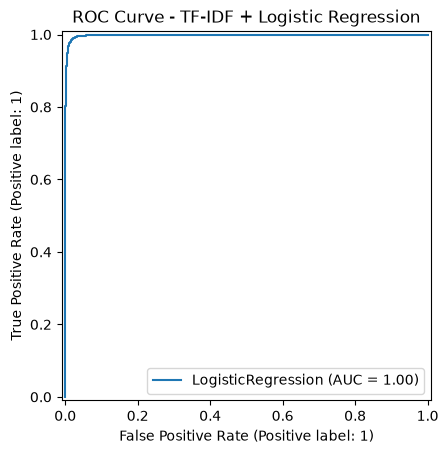

In [671]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test
)

plt.title("ROC Curve - TF-IDF + Logistic Regression")

plt.savefig("../results/roc_curve.png")

plt.show()

In [664]:
print(type(X_test))
print(X_test.shape)

<class 'pandas.Series'>
(6083,)
